# Import

In [1]:
# Import library untuk analisis data dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Untuk machine learning dan preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

# Untuk menampilkan semua kolom
pd.set_option('display.max_columns', None)

import semua library

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("parasharmanas/movie-recommendation-system")

print("Path to dataset files:", path)

100%|██████████| 165M/165M [00:02<00:00, 74.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/parasharmanas/movie-recommendation-system/versions/1


download dataset melalui path kaggle

# Load Data

In [3]:
print(os.listdir(path))

['ratings.csv', 'movies.csv']


melihat list dataset

In [4]:
movies = pd.read_csv(os.path.join(path, 'movies.csv'))
ratings = pd.read_csv(os.path.join(path, 'ratings.csv'))

menginisiasi dataset mejadi variabel

In [5]:
print('Total film yang tersedia:', len(movies.movieId.unique()))
print('Total pengguna yang memberikan rating:', len(ratings.userId.unique()))

Total film yang tersedia: 62423
Total pengguna yang memberikan rating: 162541


melihat total bedasarkan userID

# Data Understanding

In [6]:
# informasi dataset movies
movies.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62423 entries, 0 to 62422
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  62423 non-null  int64 
 1   title    62423 non-null  object
 2   genres   62423 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.4+ MB


melihat info dari movies, terdapat 3 kolom dengan total 62423 row

In [7]:
# informasi dataset ratings
ratings.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000095 entries, 0 to 25000094
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 762.9 MB


melihat info dari ratings, terdapat 4 kolom dengan total 25000095 row

In [8]:
print('\nMissing values in movies dataset:')
print(movies.isnull().sum())

print('\nMissing values in ratings dataset:')
print(ratings.isnull().sum())


Missing values in movies dataset:
movieId    0
title      0
genres     0
dtype: int64

Missing values in ratings dataset:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


melihat nilai null dari movies dan ratings, tidak ada nilai null pada kedua dataset

In [9]:
# dataset movies
movies

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
62418,209157,We (2018),Drama
62419,209159,Window of the Soul (2001),Documentary
62420,209163,Bad Poems (2018),Comedy|Drama
62421,209169,A Girl Thing (2001),(no genres listed)


melihat dataset movies

In [10]:
movies['year_of_release'] = movies.title.str.extract('([0-9]{4})')
movies.head()

,movieId,title,genres,year_of_release
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995
2,3,Grumpier Old Men (1995),Comedy|Romance,1995
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995
4,5,Father of the Bride Part II (1995),Comedy,1995


Mengekstrak tahun rilis dari kolom title dan menyimpannya ke kolom baru 'year_of_release'


In [11]:
# Mengubah tipe data kolom 'title' menjadi string
movies['title'] = movies['title'].astype(str)

# Menghapus informasi tahun (atau teks setelah tanda kurung buka) dari judul film
movies['title'] = movies['title'].str.split('(', n=1).str[0].str.strip()

movies.head()

,movieId,title,genres,year_of_release
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995
1,2,Jumanji,Adventure|Children|Fantasy,1995
2,3,Grumpier Old Men,Comedy|Romance,1995
3,4,Waiting to Exhale,Comedy|Drama|Romance,1995
4,5,Father of the Bride Part II,Comedy,1995


melihat 5 row pertama pada dataset movies, mengekstrak tahun dari judul film dan membersihkan judul film

In [12]:
ratings

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510
...,...,...,...,...
25000090,162541,50872,4.5,1240953372
25000091,162541,55768,2.5,1240951998
25000092,162541,56176,2.0,1240950697
25000093,162541,58559,4.0,1240953434


melihat dataset ratings

In [13]:
ratings.rating.unique()

array([5. , 3.5, 4. , 2.5, 4.5, 3. , 0.5, 2. , 1. , 1.5])

In [14]:
ratings['rating'] = ratings['rating'].astype(float)

mengubah tipe menjadi float

In [15]:
ratings.timestamp = pd.to_datetime(ratings['timestamp'], unit='s')
ratings.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,2006-05-17 15:34:04
1,1,306,3.5,2006-05-17 12:26:57
2,1,307,5.0,2006-05-17 12:27:08
3,1,665,5.0,2006-05-17 15:13:40
4,1,899,3.5,2006-05-17 12:21:50


melihat 5 row pertama pada dataset ratings, melihat nilai unik, mengubah semua tipe menjadi float dan Konversi timestamp

In [16]:
# Menggabungkan dataframe movies dan ratings berdasarkan kolom 'movieId' dengan metode left join
films = pd.merge(movies, ratings, on='movieId', how='left')

# Menampilkan dataframe hasil penggabungan
films

,movieId,title,genres,year_of_release,userId,rating,timestamp
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,2.0,3.5,2006-03-03 19:57:00
1,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,3.0,4.0,2015-08-13 13:23:35
2,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,4.0,3.0,2019-11-16 22:44:12
3,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,5.0,4.0,1997-03-17 19:12:29
4,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,8.0,4.0,1998-03-21 15:01:57
...,...,...,...,...,...,...,...
25003466,209157,We,Drama,2018,119571.0,1.5,2019-11-20 20:12:28
25003467,209159,Window of the Soul,Documentary,2001,115835.0,3.0,2019-11-20 20:16:25
25003468,209163,Bad Poems,Comedy|Drama,2018,6964.0,4.5,2019-11-20 21:21:53
25003469,209169,A Girl Thing,(no genres listed),2001,119571.0,3.0,2019-11-20 23:17:06


menggabungkan dataset movies dan ratings menggunakan left join dengan movieId sebagai key value

In [17]:
import sys

# Set opsi cetak NumPy agar seluruh elemen array ditampilkan tanpa dipersingkat
np.set_printoptions(threshold=sys.maxsize)

# Cetak jumlah genre unik yang ada di kolom 'genres' pada dataframe films
print('Banyak genre films: ', len(films['genres'].unique()))

# Cetak daftar lengkap genre unik pada kolom 'genres'
print('Genre films: ', films['genres'].unique())

# Kembalikan opsi cetak NumPy ke pengaturan default
np.set_printoptions(threshold=None)

Banyak genre films:  1639
Genre films:  ['Adventure|Animation|Children|Comedy|Fantasy'
 'Adventure|Children|Fantasy' 'Comedy|Romance' 'Comedy|Drama|Romance'
 'Comedy' 'Action|Crime|Thriller' 'Adventure|Children' 'Action'
 'Action|Adventure|Thriller' 'Comedy|Horror'
 'Adventure|Animation|Children' 'Drama' 'Action|Adventure|Romance'
 'Crime|Drama' 'Drama|Romance' 'Action|Comedy|Crime|Drama|Thriller'
 'Comedy|Crime|Thriller' 'Crime|Drama|Horror|Mystery|Thriller'
 'Drama|Sci-Fi' 'Children|Drama' 'Adventure|Drama|Fantasy|Mystery|Sci-Fi'
 'Mystery|Sci-Fi|Thriller' 'Adventure|Romance|IMAX' 'Documentary|IMAX'
 'Children|Comedy' 'Drama|War' 'Action|Crime|Drama'
 'Action|Adventure|Fantasy' 'Comedy|Drama|Thriller' 'Mystery|Thriller'
 'Animation|Children|Drama|Musical|Romance' 'Crime|Mystery|Thriller'
 'Action|Drama|Thriller' 'Adventure|Drama'
 'Adventure|Children|Comedy|Fantasy' 'Drama|Mystery' 'Drama|Thriller'
 'Comedy|Crime' 'Action|Sci-Fi|Thriller' 'Action|Comedy|Horror|Thriller'
 'Comedy|Dram

melakukan pengecekan genre unik

In [18]:
# show non-genre
films[films['genres'] == '(no genres listed)']

,movieId,title,genres,year_of_release,userId,rating,timestamp
22550152,83773,Away with Words,(no genres listed),1999,26031.0,3.0,2011-03-02 20:56:26
22550153,83773,Away with Words,(no genres listed),1999,72315.0,0.5,2016-04-26 19:13:25
22575388,84768,Glitterbug,(no genres listed),1994,72315.0,3.0,2015-12-15 08:07:44
22575389,84768,Glitterbug,(no genres listed),1994,119765.0,2.5,2011-02-28 06:24:03
22575390,84768,Glitterbug,(no genres listed),1994,137293.0,3.0,2011-02-28 13:20:48
...,...,...,...,...,...,...,...
25003446,209103,Tsar Ivan the Terrible,(no genres listed),1991,13737.0,4.0,2019-11-18 21:23:59
25003452,209133,The Riot and the Dance,(no genres listed),2018,127710.0,4.5,2019-11-19 17:57:15
25003453,209133,The Riot and the Dance,(no genres listed),2018,145795.0,0.5,2019-11-20 04:49:32
25003463,209151,Mao Zedong 1949,(no genres listed),1949,125475.0,3.5,2019-11-20 06:44:08


menampilkan film yang tidak punya genre

In [19]:
films = films.loc[films.genres != '(no genres listed)']
films.head()

,movieId,title,genres,year_of_release,userId,rating,timestamp
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,2.0,3.5,2006-03-03 19:57:00
1,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,3.0,4.0,2015-08-13 13:23:35
2,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,4.0,3.0,2019-11-16 22:44:12
3,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,5.0,4.0,1997-03-17 19:12:29
4,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,8.0,4.0,1998-03-21 15:01:57


menghapus film yang tidak punya genre


In [20]:
films.groupby('movieId').sum(numeric_only=True)

,userId,rating
movieId,,
1,4.658910e+09,223144.5
2,1.971155e+09,78778.0
3,9.601810e+08,37088.5
4,2.050346e+08,7199.5
5,9.488676e+08,35826.5
...,...,...
209155,1.349160e+05,5.0
209157,1.195710e+05,1.5
209159,1.158350e+05,3.0


Kelompokkan berdasarkan movieId

In [21]:
# Menghitung frekuensi kemunculan setiap movieId di dataframe films
get_values = films['movieId'].value_counts()

# Memilih movieId yang muncul setidaknya 50 kali
temp = get_values[get_values >= 50].index

# Memfilter dataframe films agar hanya menyimpan baris dengan movieId yang frekuensinya >= 50
films = films[films['movieId'].isin(temp)]

# Menampilkan dataframe hasil filter
films

,movieId,title,genres,year_of_release,userId,rating,timestamp
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,2.0,3.5,2006-03-03 19:57:00
1,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,3.0,4.0,2015-08-13 13:23:35
2,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,4.0,3.0,2019-11-16 22:44:12
3,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,5.0,4.0,1997-03-17 19:12:29
4,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,8.0,4.0,1998-03-21 15:01:57
...,...,...,...,...,...,...,...
25002983,207830,Terminator: Dark Fate,Action|Sci-Fi,2019,144301.0,3.5,2019-11-05 20:10:55
25002984,207830,Terminator: Dark Fate,Action|Sci-Fi,2019,148647.0,3.0,2019-11-05 03:28:35
25002985,207830,Terminator: Dark Fate,Action|Sci-Fi,2019,154088.0,4.0,2019-11-06 06:18:53
25002986,207830,Terminator: Dark Fate,Action|Sci-Fi,2019,154546.0,4.0,2019-11-02 14:07:44


Filter film dengan jumlah rating minimal 50

In [22]:
# duplicated by movieId
films.duplicated('movieId').sum()

np.int64(24620127)

melihat jumlah duplikat berdasarkan movieID. jumlahnya 24620127

In [23]:
# duplicated by title
films.duplicated('title').sum()

np.int64(24620647)

melihat jumlah duplikat berdasarkan movieID. jumlahnya 24620647

In [24]:
# drop duplicated data by movieId & title
films = films.drop_duplicates('movieId')
films = films.drop_duplicates('title')

Cek duplikasi berdasarkan movieId dan title lalu hapus duplikasi




Descriptive statistics of numerical columns after dropping duplicates:
             rating  year_of_release
count  12608.000000     12608.000000
mean       3.324714      1994.623652
std        1.067118        51.825366
min        0.500000      1000.000000
25%        3.000000      1986.000000
50%        3.500000      1999.000000
75%        4.000000      2008.000000
max        5.000000      5555.000000


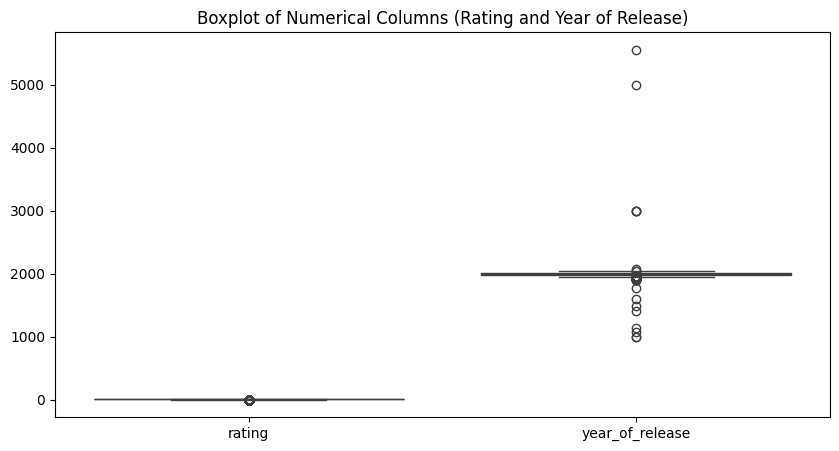


Number of outliers in 'rating' using IQR method: 790
Outliers in 'rating':
                                title  rating
132166                        Sabrina     1.0
273444                    Money Train     1.0
493127                    Richard III     1.0
666880    Indian in the Cupboard, The     0.5
674928             Mr. Holland's Opus     0.5
...                               ...     ...
24970628                What Men Want     0.5
24975072                   The Upside     0.5
24983535                   The Hustle     0.5
24986576    The Secret Life of Pets 2     1.0
24998293              It: Chapter Two     1.0

[790 rows x 2 columns]

Number of potential outliers in 'year_of_release': 18
Potential outliers in 'year_of_release':
                                                      title  year_of_release
4385927             Mystery Science Theater 3000: The Movie           3000.0
8059174                                      Murder at 1600           1600.0
15009595             

In [25]:
# Check for outliers in numerical columns after removing duplicates
# We will focus on 'rating' and potentially 'year_of_release' if treated numerically
numerical_cols = ['rating', 'year_of_release']

# Convert 'year_of_release' to numeric, handling potential errors
films['year_of_release'] = pd.to_numeric(films['year_of_release'], errors='coerce')

# Drop rows where year_of_release could not be converted (if any)
films.dropna(subset=['year_of_release'], inplace=True)

# Describe the numerical columns to get basic statistics
print("\nDescriptive statistics of numerical columns after dropping duplicates:")
print(films[numerical_cols].describe())

# Visualize outliers using boxplots for the numerical columns
plt.figure(figsize=(10, 5))
sns.boxplot(data=films[numerical_cols])
plt.title('Boxplot of Numerical Columns (Rating and Year of Release)')
plt.show()

# Identify outliers using the Interquartile Range (IQR) method for 'rating'
Q1 = films['rating'].quantile(0.25)
Q3 = films['rating'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_rating = films[(films['rating'] < lower_bound) | (films['rating'] > upper_bound)]

print(f"\nNumber of outliers in 'rating' using IQR method: {len(outliers_rating)}")
print("Outliers in 'rating':")
print(outliers_rating[['title', 'rating']])

# For 'year_of_release', outliers are usually values that are clearly incorrect
# based on historical context. We can check for unusually low or high years.
# Define a reasonable range for movie release years (e.g., 1900 to current year + 5)
current_year = pd.Timestamp.now().year
lower_year_bound = 1900
upper_year_bound = current_year + 5

outliers_year = films[(films['year_of_release'] < lower_year_bound) | (films['year_of_release'] > upper_year_bound)]

print(f"\nNumber of potential outliers in 'year_of_release': {len(outliers_year)}")
if not outliers_year.empty:
    print("Potential outliers in 'year_of_release':")
    print(outliers_year[['title', 'year_of_release']])
else:
    print("No potential outliers in 'year_of_release' found based on the defined range.")


melihat outlier dari films


Removing potential outliers in 'year_of_release' based on the defined range...
Removed 18 rows with outlier year of release.

Descriptive statistics of 'year_of_release' after outlier removal:
count    12590.000000
mean      1994.286100
std         19.415159
min       1900.000000
25%       1986.000000
50%       1999.000000
75%       2008.000000
max       2022.000000
Name: year_of_release, dtype: float64


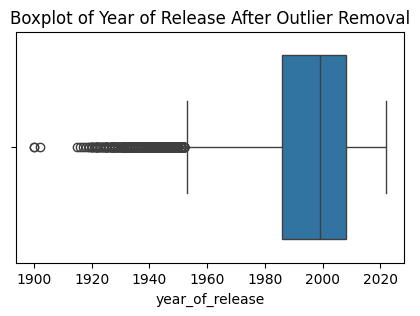

In [26]:
print("\nRemoving potential outliers in 'year_of_release' based on the defined range...")
initial_rows = len(films)
films_cleaned_year = films[(films['year_of_release'] >= lower_year_bound) & (films['year_of_release'] <= upper_year_bound)].copy()
removed_rows_year = initial_rows - len(films_cleaned_year)
print(f"Removed {removed_rows_year} rows with outlier year of release.")
films = films_cleaned_year # Update the films dataframe

# Verify the changes
print("\nDescriptive statistics of 'year_of_release' after outlier removal:")
print(films['year_of_release'].describe())

plt.figure(figsize=(5, 3))
sns.boxplot(x=films['year_of_release'])
plt.title('Boxplot of Year of Release After Outlier Removal')
plt.show()


menghapus outlier dari films

In [27]:
# Ganti string yang cocok dengan pola regex '[nS]ci-Fi' menjadi 'Scifi' di kolom 'genres'
films['genres'] = films['genres'].str.replace('[nS]ci-Fi', 'Scifi', regex=True)

films.head()

,movieId,title,genres,year_of_release,userId,rating,timestamp
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995.0,2.0,3.5,2006-03-03 19:57:00
57309,2,Jumanji,Adventure|Children|Fantasy,1995.0,9.0,5.0,1997-03-26 13:32:22
81537,3,Grumpier Old Men,Comedy|Romance,1995.0,8.0,4.0,1998-03-21 15:08:26
93341,4,Waiting to Exhale,Comedy|Drama|Romance,1995.0,141.0,3.0,1996-07-30 07:29:46
95864,5,Father of the Bride Part II,Comedy,1995.0,18.0,4.0,2005-02-13 05:52:25


Ganti string yang cocok dengan pola regex '[nS]ci-Fi' menjadi 'Scifi' di kolom 'genres'


In [28]:
# Membuat salinan dataframe films ke variabel preparation
preparation = films
preparation.sort_values(by='movieId').head()

,movieId,title,genres,year_of_release,userId,rating,timestamp
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995.0,2.0,3.5,2006-03-03 19:57:00
57309,2,Jumanji,Adventure|Children|Fantasy,1995.0,9.0,5.0,1997-03-26 13:32:22
81537,3,Grumpier Old Men,Comedy|Romance,1995.0,8.0,4.0,1998-03-21 15:08:26
93341,4,Waiting to Exhale,Comedy|Drama|Romance,1995.0,141.0,3.0,1996-07-30 07:29:46
95864,5,Father of the Bride Part II,Comedy,1995.0,18.0,4.0,2005-02-13 05:52:25


Duplikasi dataframe ke preparation`

In [29]:
# Mengubah kolom 'movieId' pada dataframe preparation menjadi list
film_id = preparation['movieId'].to_list()

# Mengubah kolom 'title' pada dataframe preparation menjadi list
film_name = preparation['title'].to_list()

# Mengubah kolom 'genres' pada dataframe preparation menjadi list
film_genre = preparation['genres'].to_list()

# Menampilkan panjang masing-masing list
print(len(film_id))
print(len(film_name))
print(len(film_genre))

12590
12590
12590


Buat list ID, nama, genre film


In [30]:
# Membuat dataframe dari dictionary yang berisi list film_id, film_name, dan film_genre
df_film = pd.DataFrame(data={
    'film_id': film_id,
    'film_name': film_name,
    'genre': film_genre
})
df_film

,film_id,film_name,genre
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji,Adventure|Children|Fantasy
2,3,Grumpier Old Men,Comedy|Romance
3,4,Waiting to Exhale,Comedy|Drama|Romance
4,5,Father of the Bride Part II,Comedy
...,...,...,...
12585,205076,Downton Abbey,Drama
12586,205383,El Camino: A Breaking Bad Movie,Crime|Drama|Thriller
12587,205425,Dave Chappelle: Sticks & Stones,Comedy
12588,206499,Between Two Ferns: The Movie,Comedy


Buat dataframe baru untuk TF-IDF

In [31]:
# data sample
data = df_film
data.head()

,film_id,film_name,genre
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji,Adventure|Children|Fantasy
2,3,Grumpier Old Men,Comedy|Romance
3,4,Waiting to Exhale,Comedy|Drama|Romance
4,5,Father of the Bride Part II,Comedy


 Data sample

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Membuat objek TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Melatih model TF-IDF pada kolom 'genre' dari dataframe data
tfidf_vectorizer.fit(data['genre'])

# Mendapatkan daftar fitur (kata) yang dihasilkan oleh TfidfVectorizer
tfidf_vectorizer.get_feature_names_out()

array(['action', 'adventure', 'animation', 'children', 'comedy', 'crime',
       'documentary', 'drama', 'fantasy', 'film', 'horror', 'imax',
       'musical', 'mystery', 'noir', 'romance', 'scifi', 'thriller',
       'war', 'western'], dtype=object)

Fit TF-IDF pada genre

In [33]:
# fit & transform to matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(data['genre'])

# show matrix dimension
tfidf_matrix.shape

(12590, 20)

Transformasi TF-IDF

In [34]:
# Mengubah vektor tf-idf menjadi bentuk matriks padat (dense matrix)
tfidf_matrix.todense()

matrix([[0.        , 0.42084217, 0.51609073, 0.49850385, 0.26674478,
         0.        , 0.        , 0.        , 0.48670665, 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.51704352, 0.        , 0.61245808, 0.        ,
         0.        , 0.        , 0.        , 0.59796413, 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.58157362,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.81349378, 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.52073859,
         0.        , 0.        , 0.44527107, 0.        , 0.        ,
         0.        , 0.        

Lihat matriks padat

In [35]:
# Membuat dataframe dari matriks tf-idf dengan baris sebagai film_name dan kolom sebagai genre
pd.DataFrame(
    tfidf_matrix.todense(),
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=data.film_name
).sample(n=20, axis=1).sample(n=10, axis=0)

,animation,thriller,fantasy,adventure,war,musical,crime,romance,western,documentary,action,mystery,horror,comedy,noir,children,imax,scifi,film,drama
film_name,,,,,,,,,,,,,,,,,,,,
Captain Horatio Hornblower R.N.,0.0,0.000000,0.0,0.515110,0.670911,0.0,0.000000,0.000000,0.0,0.000000,0.454532,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.279178
U-571,0.0,0.465264,0.0,0.000000,0.732828,0.0,0.000000,0.000000,0.0,0.000000,0.496479,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000
Deep Sea 3D,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.591667,0.000000,0.0,0.0,0.000000,0.0,0.0,0.806182,0.000000,0.0,0.000000
Casual Sex?,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,1.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000
To Live and Die in L.A.,0.0,0.502408,0.0,0.000000,0.000000,0.0,0.593075,0.000000,0.0,0.000000,0.536114,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.329287
Baby... Secret of the Lost Legend,0.0,0.000000,0.0,0.681668,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.731662,0.0,0.000000
Drunks,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,1.000000
Don Jon,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.728399,0.0,0.000000,0.000000,0.0,0.0,0.520739,0.0,0.0,0.000000,0.000000,0.0,0.445271
Ray,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,1.000000


Tampilkan sebagian besar matriks

In [36]:
print(tfidf_matrix.shape)
print(type(tfidf_matrix))

(12590, 20)
<class 'scipy.sparse._csr.csr_matrix'>


 Info bentuk matriks

In [37]:
# total data
n = tfidf_matrix.shape[0]

# ambil 10000 indeks acak tanpa pengulangan
random_indices = np.random.choice(n, size=10000, replace=False)

# ambil subset sparse matrix berdasarkan indeks acak
subset_matrix = tfidf_matrix[random_indices]

# hitung cosine similarity pada subset acak ini
cosine_sim_subset = cosine_similarity(subset_matrix)

# contoh: film nama yang diambil sesuai index acak
subset_film_names = data.film_name.iloc[random_indices].tolist()

Sampling untuk cosine similarity

In [38]:
cosine_sim_df = pd.DataFrame(
    cosine_sim_subset,
    index=subset_film_names,
    columns=subset_film_names
)
print('Shape:', cosine_sim_df.shape)
cosine_sim_df.sample(5, axis=1).sample(10, axis=0)

Shape: (10000, 10000)


,Broken English,"Champ, The","Princess Bride, The",Mad Max Beyond Thunderdome,Chronicles
No Holds Barred,0.000000,0.000000,0.425335,0.515442,0.000000
Bella,0.521568,0.521568,0.364627,0.000000,0.253179
Man's Favorite Sport?,0.000000,0.000000,0.305523,0.000000,0.000000
My Cousin Rachel,0.521568,0.521568,0.364627,0.000000,0.253179
Diamond Men,1.000000,1.000000,0.000000,0.000000,0.485419
Taken,0.329287,0.329287,0.228028,0.276336,0.678357
Bringing Down the House,0.000000,0.000000,0.305523,0.000000,0.000000
"Trouble with Angels, The",0.000000,0.000000,0.305523,0.000000,0.000000
Power/Rangers,0.000000,0.000000,0.500803,1.000000,0.000000
Pokémon the Movie 2000,0.000000,0.000000,0.000000,0.000000,0.000000


Buat dataframe cosine similarity

In [39]:
def film_recommendations(film_name, similarity_data=cosine_sim_df, items=None, k=10, return_metadata=False):
    """
    Memberikan rekomendasi film berdasarkan kemiripan cosine similarity.

    Parameters:
    - film_name: Judul film sebagai basis.
    - similarity_data: DataFrame cosine similarity antar film.
    - items: DataFrame berisi metadata film, minimal kolom 'film_name' dan lainnya jika return_metadata=True.
    - k: Jumlah rekomendasi yang ingin dikembalikan.
    - return_metadata: Jika True, mengembalikan DataFrame dengan metadata; jika False, hanya list nama film.

    Returns:
    - List nama film atau DataFrame dengan metadata.
    """
    if film_name not in similarity_data.columns:
        print(f"Film '{film_name}' tidak ditemukan dalam similarity data.")
        return [] if not return_metadata else pd.DataFrame()

    # Urutkan skor kemiripan, abaikan film itu sendiri
    similarity_scores = similarity_data[film_name].sort_values(ascending=False)
    top_indices = similarity_scores.iloc[1:k+1].index  # skip self

    if return_metadata:
        if items is None:
            raise ValueError("Parameter 'items' harus disediakan jika return_metadata=True")
        return pd.DataFrame(top_indices, columns=['film_name']).merge(items, on='film_name', how='left')
    else:
        return list(top_indices)


Fungsi rekomendasi berdasarkan nama film

In [40]:
# sample data
data.sample(3)

,film_id,film_name,genre
256,270,Love Affair,Drama|Romance
8159,49130,"Good Year, A",Comedy|Drama|Romance
9287,71318,Terra,Adventure|Animation|Scifi


In [41]:
data[data.film_name.eq('The Raid 2: Berandal')]


,film_id,film_name,genre
10845,110501,The Raid 2: Berandal,Action|Crime|Thriller


Cek film tertentu

In [42]:
film_recommendations('The Raid 2: Berandal')

['Highwaymen',
 'Natural Born Killers',
 'Dirty Carnival, A',
 'Transporter 2',
 'A Hard Day',
 'French Connection, The',
 'U.S. Marshals',
 'Hitman: Agent 47',
 'Last Stand, The',
 'Hitman, The']

Coba rekomendasi berdasarkan nama film

In [43]:
df = preparation
df

,movieId,title,genres,year_of_release,userId,rating,timestamp
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995.0,2.0,3.5,2006-03-03 19:57:00
57309,2,Jumanji,Adventure|Children|Fantasy,1995.0,9.0,5.0,1997-03-26 13:32:22
81537,3,Grumpier Old Men,Comedy|Romance,1995.0,8.0,4.0,1998-03-21 15:08:26
93341,4,Waiting to Exhale,Comedy|Drama|Romance,1995.0,141.0,3.0,1996-07-30 07:29:46
95864,5,Father of the Bride Part II,Comedy,1995.0,18.0,4.0,2005-02-13 05:52:25
...,...,...,...,...,...,...,...
25000108,205076,Downton Abbey,Drama,2019.0,2111.0,4.5,2019-11-05 01:46:17
25000617,205383,El Camino: A Breaking Bad Movie,Crime|Drama|Thriller,2019.0,1099.0,5.0,2019-10-17 09:33:22
25000936,205425,Dave Chappelle: Sticks & Stones,Comedy,2019.0,2165.0,2.0,2019-09-08 01:32:54
25001872,206499,Between Two Ferns: The Movie,Comedy,2019.0,847.0,2.0,2019-09-29 05:01:05


Simpan df preparation

In [44]:
# ubah nilai unik dari 'userId' menjadi list
user_ids = list(set(df['userId']))
print('list userID: ', user_ids)

# encode 'userId'
user_to_user_encoded = dict(zip(user_ids, range(len(user_ids))))
print('encoded userID : ', user_to_user_encoded)

# encoding index ke 'userId'
user_encoded_to_user = dict(zip(range(len(user_ids)), user_ids))
print('encoded angka ke userID: ', user_encoded_to_user)

list userID:  [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 8215.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 50.0, 51.0, 52.0, 53.0, 55.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 72.0, 73.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 82.0, 83.0, 84.0, 85.0, 86.0, 88.0, 91.0, 93.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0, 101.0, 102.0, 103.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 120.0, 121.0, 123.0, 124.0, 125.0, 128.0, 129.0, 130.0, 131.0, 132.0, 133.0, 135.0, 137.0, 138.0, 139.0, 141.0, 142.0, 144.0, 145.0, 146.0, 147.0, 148.0, 149.0, 151.0, 152.0, 153.0, 154.0, 155.0, 156.0, 157.0, 158.0, 159.0, 160.0, 161.0, 162.0, 163.0, 164.0, 166.0, 167.0, 169.0, 171.0, 172.0, 173.0, 174.0, 175.0, 16559.0, 177.0, 178.0, 179.0, 8369

Encode userId

In [45]:
# ubah nilai unik dari 'movieId' menjadi list
films_ids = list(set(df['movieId']))

# encode 'movieId'
films_to_films_encoded = dict(zip(films_ids, range(len(films_ids))))

# encoding index ke 'movieId'
films_encoded_to_films = dict(zip(range(len(films_ids)), films_ids))

Encode movieId

In [46]:
# Menambahkan kolom 'user' berdasarkan hasil encoding 'userId'
df.loc[:, 'user'] = df['userId'].apply(lambda x: user_to_user_encoded[x])

# Menambahkan kolom 'films' berdasarkan hasil encoding 'movieId'
df.loc[:, 'films'] = df['movieId'].apply(lambda x: films_to_films_encoded[x])

Tambahkan kolom encoded user dan film

In [47]:
# Menghitung jumlah user unik
num_users = df['user'].nunique()
print(num_users)

# Menghitung jumlah film unik
num_films = df['films'].nunique()
print(num_films)

# Mengubah tipe data rating menjadi float32
df['rating'] = df['rating'].astype('float32')

# Mengambil nilai rating minimum dan maksimum
min_rating = df['rating'].min()
max_rating = df['rating'].max()

# Menampilkan informasi jumlah user, film, dan nilai rating
print(f'Number of User: {num_users}, Number of Films: {num_films}, Min Rating: {min_rating}, Max Rating: {max_rating}')

1411
12590
Number of User: 1411, Number of Films: 12590, Min Rating: 0.5, Max Rating: 5.0


Info jumlah user dan film

In [48]:
# sampling
df = df.sample(frac=1, random_state=42)
df

,movieId,title,genres,year_of_release,userId,rating,timestamp,user,films
21357427,60684,Watchmen,Action|Drama|Mystery|Scifi|Thriller|IMAX,2009.0,3.0,4.5,2015-08-13 14:04:18,2,11590
24569979,159415,Swiss Army Man,Comedy|Drama|Romance,2016.0,406.0,5.0,2016-10-23 03:16:18,296,11671
13807399,3534,28 Days,Drama,2000.0,3.0,3.0,2015-08-13 13:39:40,2,3374
24364030,138202,Burying the Ex,Comedy|Horror,2015.0,548.0,2.0,2015-10-16 23:50:26,377,3225
22575453,84772,Paul,Adventure|Comedy|Scifi,2011.0,3.0,3.5,2017-01-18 16:13:08,2,9649
...,...,...,...,...,...,...,...,...,...
24660182,165639,While You Were Fighting: A Thor Mockumentary,Comedy|Fantasy|Scifi,2016.0,1503.0,4.0,2017-03-06 19:45:26,728,1721
17202076,6072,"Unfaithful Wife, The",Drama|Thriller,1969.0,4532.0,4.5,2003-06-09 00:23:46,1222,5778
17368926,6345,"Chorus Line, A",Comedy|Drama|Musical,1985.0,226.0,0.5,2003-07-29 19:16:56,186,6014
5364139,967,"Outlaw, The",Western,1943.0,72.0,3.0,2001-03-13 17:02:24,64,937


Shuffle data

In [49]:
from sklearn.model_selection import train_test_split

# Mengambil fitur user dan films
x = df[['user', 'films']].values

# Normalisasi rating ke rentang 0-1
y = df['rating'].apply(lambda r: (r - min_rating) / (max_rating - min_rating)).values

# Membagi data menjadi training dan validation dengan proporsi 80:20 secara acak
x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, random_state=42, shuffle=True
)

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)

(10072, 2) (10072,)
(2518, 2) (2518,)


Pisahkan fitur dan label

# content-based filtering

In [50]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

class RecommenderNet(tf.keras.Model):

    def __init__(self, num_users, num_films, embedding_size, **kwargs):
        super().__init__(**kwargs)
        self.num_users = num_users
        self.num_films = num_films
        self.embedding_size = embedding_size

        # User embedding dan bias
        self.user_embedding = layers.Embedding(
            input_dim=num_users,
            output_dim=embedding_size,
            embeddings_initializer='he_normal',
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )
        self.user_bias = layers.Embedding(num_users, 1)

        # Film embedding dan bias
        self.films_embedding = layers.Embedding(
            input_dim=num_films,
            output_dim=embedding_size,
            embeddings_initializer='he_normal',
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )
        self.films_bias = layers.Embedding(num_films, 1)

    def call(self, inputs):
        user_vector = self.user_embedding(inputs[:, 0])
        user_bias = self.user_bias(inputs[:, 0])
        films_vector = self.films_embedding(inputs[:, 1])
        films_bias = self.films_bias(inputs[:, 1])

        # Menghitung hasil dot product antara user dan film embedding
        dot_product = tf.reduce_sum(user_vector * films_vector, axis=1, keepdims=True)

        # Menjumlahkan dot product dengan bias user dan film
        x = dot_product + user_bias + films_bias

        return tf.nn.sigmoid(x)


Buat arsitektur RecommenderNet

In [51]:
model = RecommenderNet(num_users, num_films, 50) # model initialization

# model compile
model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)


Kompilasi model

In [52]:
# Callback untuk early stopping (opsional)
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3)

# Latih ulang model
history = model.fit(
    x = x_train,
    y = y_train,
    batch_size = 32,
    epochs = 50,
    validation_data = (x_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.6900 - root_mean_squared_error: 0.2655 - val_loss: 0.6806 - val_root_mean_squared_error: 0.2598
Epoch 2/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.6700 - root_mean_squared_error: 0.2452 - val_loss: 0.6724 - val_root_mean_squared_error: 0.2514
Epoch 3/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.6307 - root_mean_squared_error: 0.2037 - val_loss: 0.6684 - val_root_mean_squared_error: 0.2466
Epoch 4/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.5903 - root_mean_squared_error: 0.1550 - val_loss: 0.6665 - val_root_mean_squared_error: 0.2439
Epoch 5/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.5677 - root_mean_squared_error: 0.1193 - val_loss: 0.6660 - val_root_mean_squared_error: 0.2426
Epoch 6/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.5529 - root_mean_squared_error: 0.0922 - val_loss: 0.6653 - val_root_mean_squared_error: 0.2412
Epoch 7/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 6s 13m

Training model

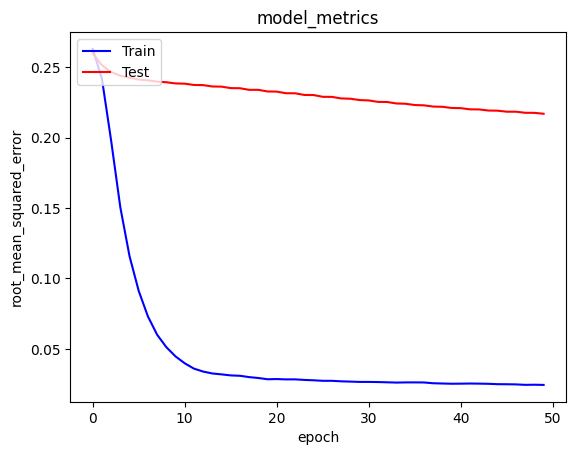

In [53]:
# plot metrics evaluations
plt.plot(history.history['root_mean_squared_error'], color='blue')
plt.plot(history.history['val_root_mean_squared_error'], color='red')
plt.title('model_metrics')
plt.ylabel('root_mean_squared_error')
plt.xlabel('epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


Visualisasi evaluasi

In [54]:
# films
films_df = df_film
films_df.head()

,film_id,film_name,genre
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji,Adventure|Children|Fantasy
2,3,Grumpier Old Men,Comedy|Romance
3,4,Waiting to Exhale,Comedy|Drama|Romance
4,5,Father of the Bride Part II,Comedy


Siapkan data film

In [55]:
# data ratings
df = films
df.head()

,movieId,title,genres,year_of_release,userId,rating,timestamp,user,films
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995.0,2.0,3.5,2006-03-03 19:57:00,1,0
57309,2,Jumanji,Adventure|Children|Fantasy,1995.0,9.0,5.0,1997-03-26 13:32:22,8,1
81537,3,Grumpier Old Men,Comedy|Romance,1995.0,8.0,4.0,1998-03-21 15:08:26,7,2
93341,4,Waiting to Exhale,Comedy|Drama|Romance,1995.0,141.0,3.0,1996-07-30 07:29:46,119,3
95864,5,Father of the Bride Part II,Comedy,1995.0,18.0,4.0,2005-02-13 05:52:25,17,4


Gunakan dataframe utama

In [56]:
# Memilih user aktif (yang telah memberi rating ≥ 50)
user_counts = df.groupby('userId').size()
active_users = user_counts[user_counts >= 50].index.tolist()

# Check if active_users is empty
if not active_users:
    print("No active users found with 50 or more ratings in the filtered dataset.")
    # You might want to exit or handle this case appropriately,
    # depending on how you want to proceed when no such users exist.
    # For demonstration, we'll just print and skip the recommendation logic below.
else:
    # Mengambil satu user aktif secara acak
    user_id = np.random.choice(active_users)

    # Film yang sudah ditonton oleh user tersebut
    films_visited_by_user = df[df['userId'] == user_id]

    # Film yang belum ditonton user
    films_not_visited = films_df.loc[
        ~films_df['film_id'].isin(films_visited_by_user['movieId'].values), 'film_id'
    ]

    # Filter film yang ada dalam encoding
    films_not_visited = list(set(films_not_visited).intersection(set(films_to_films_encoded.keys())))

    # Buat list encoded film yang belum ditonton
    films_not_visited = [[films_to_films_encoded[x]] for x in films_not_visited]

    # Ambil encoded user
    user_encoder = user_to_user_encoded[user_id]

    # Buat array kombinasi user + film
    user_films_array = np.hstack((
        np.full((len(films_not_visited), 1), user_encoder),
        films_not_visited
    ))

    # --- The rest of your recommendation logic would go here, inside this else block ---
    # Prediksi rating film yang belum ditonton user
    ratings = model.predict(user_films_array).flatten()

    # Ambil indeks 10 rating tertinggi secara terbalik (descending)
    top_ratings_indices = np.argsort(ratings)[-10:][::-1]

    # Mapping indeks ke film_id asli
    recommended_films_ids = [films_encoded_to_films[films_not_visited[i][0]] for i in top_ratings_indices]

    print(f"Showing recommendations for users: {user_id}")
    print("===" * 9)
    print("Films with high ratings from user")
    print("----" * 8)

    # Ambil 5 film dengan rating tertinggi yang sudah ditonton user
    top_films_user = films_visited_by_user.sort_values(by='rating', ascending=False).head(5)['movieId'].values

    # Tampilkan nama dan genre film yang sudah ditonton
    for _, row in films_df[films_df['film_id'].isin(top_films_user)].iterrows():
        print(f"{row.film_name} : {row.genre}")

    print("----" * 8)
    print("Top 10 films recommendation")
    print("----" * 8)

    # Tampilkan rekomendasi film berdasarkan prediksi model
    for _, row in films_df[films_df['film_id'].isin(recommended_films_ids)].iterrows():
        print(f"{row.film_name} : {row.genre}")

392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Showing recommendations for users: 84.0
Films with high ratings from user
--------------------------------
Paris, Texas : Drama|Romance
Solaris : Drama|Mystery|Scifi
Dancer in the Dark : Drama|Musical
Let the Right One In : Drama|Fantasy|Horror|Romance
Toni Erdmann : Drama
--------------------------------
Top 10 films recommendation
--------------------------------
While You Were Sleeping : Comedy|Romance
In Love and War : Romance|War
For Roseanna : Comedy|Drama|Romance
Adventures of Buckaroo Banzai Across the 8th Dimension, The : Adventure|Comedy|Scifi
House of Games : Crime|Film-Noir|Mystery|Thriller
Osama : Drama
Dogville : Drama|Mystery|Thriller
Turtles Can Fly : Drama|War
Dr. Horrible's Sing-Along Blog : Comedy|Drama|Musical|Scifi
Wadjda : Drama


In [57]:
# Prediksi rating film yang belum ditonton user
ratings = model.predict(user_films_array).flatten()

# Ambil indeks 10 rating tertinggi secara terbalik (descending)
top_ratings_indices = np.argsort(ratings)[-10:][::-1]

# Mapping indeks ke film_id asli
recommended_films_ids = [films_encoded_to_films[films_not_visited[i][0]] for i in top_ratings_indices]

print(f"Showing recommendations for users: {user_id}")
print("===" * 9)
print("Films with high ratings from user")
print("----" * 8)

# Ambil 5 film dengan rating tertinggi yang sudah ditonton user
top_films_user = films_visited_by_user.sort_values(by='rating', ascending=False).head(5)['movieId'].values

# Tampilkan nama dan genre film yang sudah ditonton
for _, row in films_df[films_df['film_id'].isin(top_films_user)].iterrows():
    print(f"{row.film_name} : {row.genre}")

print("----" * 8)
print("Top 10 films recommendation")
print("----" * 8)

# Tampilkan rekomendasi film berdasarkan prediksi model
for _, row in films_df[films_df['film_id'].isin(recommended_films_ids)].iterrows():
    print(f"{row.film_name} : {row.genre}")

392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Showing recommendations for users: 84.0
Films with high ratings from user
--------------------------------
Paris, Texas : Drama|Romance
Solaris : Drama|Mystery|Scifi
Dancer in the Dark : Drama|Musical
Let the Right One In : Drama|Fantasy|Horror|Romance
Toni Erdmann : Drama
--------------------------------
Top 10 films recommendation
--------------------------------
While You Were Sleeping : Comedy|Romance
In Love and War : Romance|War
For Roseanna : Comedy|Drama|Romance
Adventures of Buckaroo Banzai Across the 8th Dimension, The : Adventure|Comedy|Scifi
House of Games : Crime|Film-Noir|Mystery|Thriller
Osama : Drama
Dogville : Drama|Mystery|Thriller
Turtles Can Fly : Drama|War
Dr. Horrible's Sing-Along Blog : Comedy|Drama|Musical|Scifi
Wadjda : Drama


Prediksi dan tampilkan rekomendasi

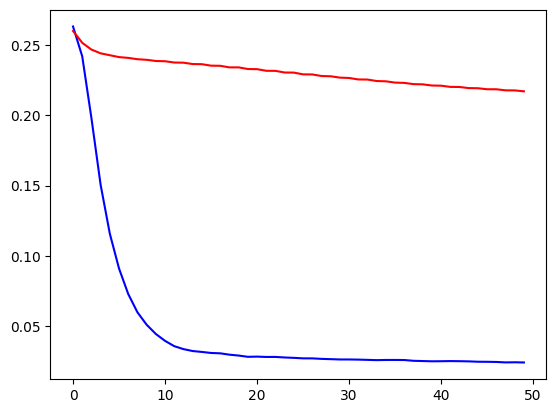

In [58]:
plt.plot(history.history['root_mean_squared_error'], color='blue')
plt.plot(history.history['val_root_mean_squared_error'], color='red')

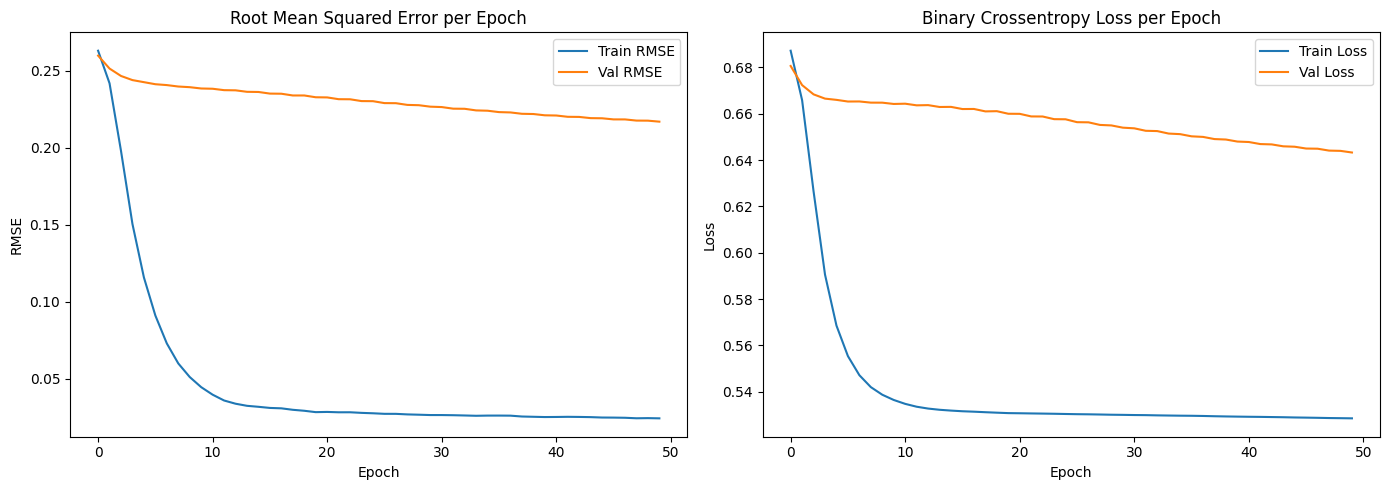

In [59]:
# Plot RMSE dan Loss selama pelatihan
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
ax[0].plot(history.history['root_mean_squared_error'], label='Train RMSE')
ax[0].plot(history.history['val_root_mean_squared_error'], label='Val RMSE')
ax[0].set_title('Root Mean Squared Error per Epoch')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('RMSE')
ax[0].legend()

# Loss
ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Binary Crossentropy Loss per Epoch')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()


Visualisasi RMSE dan Loss

In [60]:
def precision_at_k(recommended_ids, user_id, k=10):
    # Ambil semua film yang disukai user (rating >= 4)
    liked_by_user = df[(df['userId'] == user_id) & (df['rating'] >= 4)]['movieId'].values

    # Hitung berapa dari top-k rekomendasi yang termasuk dalam daftar liked_by_user
    hits = [film for film in recommended_ids[:k] if film in liked_by_user]
    precision = len(hits) / k

    print(f"Precision@{k}: {precision:.2f}")
    return precision


In [69]:
from sklearn.metrics import precision_score, recall_score
import math

def precision_at_k(recommended_items, relevant_items, k=10):

    if not recommended_items or k <= 0:
        return 0.0

    recommended_at_k = set(recommended_items[:k])
    relevant_at_k = set(relevant_items)

    intersection = recommended_at_k.intersection(relevant_at_k)
    return len(intersection) / min(k, len(recommended_at_k)) # Use min to handle cases where recommended_items < k


def recall_at_k(recommended_items, relevant_items, k=10):

    if not relevant_items or k <= 0:
        return 0.0

    recommended_at_k = set(recommended_items[:k])
    relevant_at_k = set(relevant_items)

    intersection = recommended_at_k.intersection(relevant_at_k)
    return len(intersection) / len(relevant_at_k)

def ndcg_at_k(recommended_items, relevant_items_with_scores, k=10):

    if not recommended_items or k <= 0:
        return 0.0

    # Convert relevant items to a dictionary for easy lookup
    if isinstance(relevant_items_with_scores, list):
        relevant_scores_dict = dict(relevant_items_with_scores)
    elif isinstance(relevant_items_with_scores, dict):
        relevant_scores_dict = relevant_items_with_scores
    else:
        raise ValueError("relevant_items_with_scores must be a dictionary or a list of tuples")

    dcg = 0.0
    idcg = 0.0

    # Calculate DCG@K
    for i in range(min(k, len(recommended_items))):
        item_id = recommended_items[i]
        # Get relevance score, default to 0 if not in relevant_items_with_scores
        relevance_score = relevant_scores_dict.get(item_id, 0)
        dcg += relevance_score / math.log2(i + 2)  # i is 0-indexed, so position is i+1

    # Calculate IDCG@K (Ideal DCG)
    # Get all relevant scores and sort them in descending order
    ideal_relevant_scores = sorted(relevant_scores_dict.values(), reverse=True)

    for i in range(min(k, len(ideal_relevant_scores))):
        idcg += ideal_relevant_scores[i] / math.log2(i + 2)

    if idcg == 0:
        return 0.0 # Cannot normalize if ideal DCG is 0

    return dcg / idcg


# Example Usage (using the existing variables like recommended_films_ids and films_visited_by_user)

# First, define the relevant items for the selected user (user_id).
# Let's consider films with a rating >= 4 as relevant.
relevant_films_for_user = films_visited_by_user[films_visited_by_user['rating'] >= 4]
relevant_film_ids = relevant_films_for_user['movieId'].tolist()

# For NDCG, we need relevance scores. We can use the actual ratings.
# Ensure relevant_items_with_scores is a dict of item_id: rating
relevant_films_with_scores_dict = relevant_films_for_user[['movieId', 'rating']].set_index('movieId').to_dict()['rating']


k_value = 10 # Define the K for evaluation

if 'recommended_films_ids' in locals(): # Check if recommendations were generated
    # Calculate Precision@K
    precision = precision_at_k(recommended_films_ids, relevant_film_ids, k=k_value)
    print(f"Precision@{k_value}: {precision:.4f}")

    # Calculate Recall@K
    recall = recall_at_k(recommended_films_ids, relevant_film_ids, k=k_value)
    print(f"Recall@{k_value}: {recall:.4f}")

    # Calculate NDCG@K
    ndcg = ndcg_at_k(recommended_films_ids, relevant_films_with_scores_dict, k=k_value)
    print(f"NDCG@{k_value}: {ndcg:.4f}")
else:
    print("No recommendations were generated. Cannot calculate metrics.")


Precision@10: 0.0000
Recall@10: 0.0000
NDCG@10: 0.0000


Evaluasi Precision@K, Recall@K, atau NDCG@K

# collaborative filtering

In [62]:
class RecommenderNet(tf.keras.Model):
    def __init__(self, num_users, num_items, embedding_size):
        super().__init__()
        self.user_embedding = layers.Embedding(num_users, embedding_size)
        self.item_embedding = layers.Embedding(num_items, embedding_size)
        self.user_bias = layers.Embedding(num_users, 1)
        self.item_bias = layers.Embedding(num_items, 1)

    def call(self, inputs):
        user_vec = self.user_embedding(inputs[:, 0])
        item_vec = self.item_embedding(inputs[:, 1])
        dot = tf.reduce_sum(user_vec * item_vec, axis=1, keepdims=True)
        return tf.nn.sigmoid(dot + self.user_bias(inputs[:, 0]) + self.item_bias(inputs[:, 1]))


Arsitektur Model


In [63]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

history = model.fit(
    x_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(x_val, y_val)
)

Epoch 1/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.5305 - root_mean_squared_error: 0.0384 - val_loss: 0.6410 - val_root_mean_squared_error: 0.2161
Epoch 2/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.5301 - root_mean_squared_error: 0.0368 - val_loss: 0.6409 - val_root_mean_squared_error: 0.2158
Epoch 3/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.5291 - root_mean_squared_error: 0.0305 - val_loss: 0.6408 - val_root_mean_squared_error: 0.2154
Epoch 4/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.5318 - root_mean_squared_error: 0.0301 - val_loss: 0.6408 - val_root_mean_squared_error: 0.2154
Epoch 5/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.5307 - root_mean_squared_error: 0.0283 - val_loss: 0.6405 - val_root_mean_squared_error: 0.2150
Epoch 6/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.5275 - root_mean_squared_error: 0.0274 - val_loss: 0.6406 - val_root_mean_squared_error: 0.2150
Epoch 7/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 5s 11m

Pelatihan Model

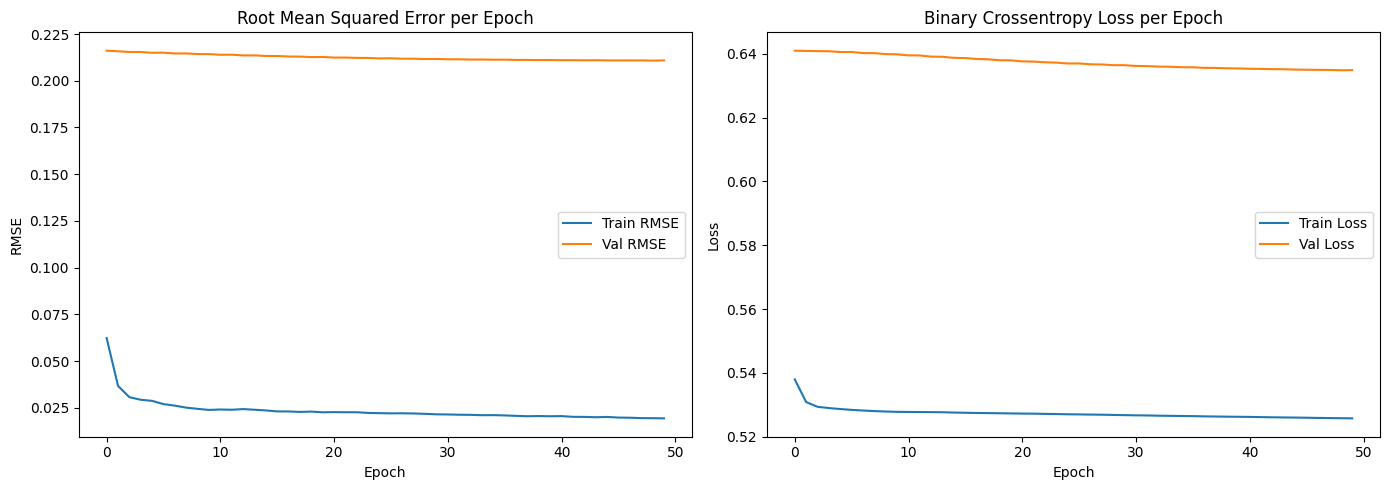

In [64]:
# Plot RMSE dan Loss selama pelatihan
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
ax[0].plot(history.history['root_mean_squared_error'], label='Train RMSE')
ax[0].plot(history.history['val_root_mean_squared_error'], label='Val RMSE')
ax[0].set_title('Root Mean Squared Error per Epoch')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('RMSE')
ax[0].legend()

# Loss
ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Binary Crossentropy Loss per Epoch')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()

Visualisasi RMSE dan Loss

In [65]:
# Pilih user aktif
user_counts = df.groupby('userId').size()
active_users = user_counts[user_counts >= 50].index.tolist()
user_id = np.random.choice(active_users)

# Film yang sudah ditonton oleh user tersebut
films_visited_by_user = df[df['userId'] == user_id]

# Film yang belum ditonton user
films_not_visited = films_df.loc[
    ~films_df['film_id'].isin(films_visited_by_user['movieId'].values), 'film_id'
]

films_not_visited = list(set(films_not_visited).intersection(set(films_to_films_encoded.keys())))
films_not_visited = [[films_to_films_encoded[x]] for x in films_not_visited]

user_encoder = user_to_user_encoded[user_id]
user_films_array = np.hstack((
    np.full((len(films_not_visited), 1), user_encoder),
    films_not_visited
))

 Pilih User Aktif dan Prediksi

In [66]:
ratings = model.predict(user_films_array).flatten()
top_ratings_indices = np.argsort(ratings)[-10:][::-1]
recommended_films_ids = [films_encoded_to_films[films_not_visited[i][0]] for i in top_ratings_indices]

print(f"Rekomendasi untuk user {user_id}")
print("===" * 10)

print("5 Film yang disukai user:")
top_films_user = films_visited_by_user.sort_values(by='rating', ascending=False).head(5)['movieId'].values
for _, row in films_df[films_df['film_id'].isin(top_films_user)].iterrows():
    print(f"{row.film_name} : {row.genre}")

print("===" * 10)
print("10 Rekomendasi Teratas:")
for _, row in films_df[films_df['film_id'].isin(recommended_films_ids)].iterrows():
    print(f"{row.film_name} : {row.genre}")

391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Rekomendasi untuk user 80.0
5 Film yang disukai user:
Dead Presidents : Action|Crime|Drama
Fan, The : Drama|Thriller
Desperate Measures : Crime|Drama|Thriller
U Turn : Crime|Drama|Mystery
Way of the Gun, The : Crime|Thriller
10 Rekomendasi Teratas:
Body Snatchers : Horror|Scifi|Thriller
In Love and War : Romance|War
On Any Sunday : Documentary
Texasville : Drama
Tai Chi Master : Action|Adventure|Comedy|Drama
Pentagon Wars, The : Comedy|War
Celine and Julie Go Boating : Drama|Fantasy|Mystery
Ex Drummer : Comedy|Crime|Drama|Horror
Scenic Route : Drama|Thriller
Borgman : Thriller


Prediksi & Cetak Hasil Rekomendasi

In [67]:
def precision_at_k(recommended_ids, user_id, k=10):
    liked_by_user = df[(df['userId'] == user_id) & (df['rating'] >= 4)]['movieId'].values
    hits = [film for film in recommended_ids[:k] if film in liked_by_user]
    precision = len(hits) / k
    print(f"Precision@{k}: {precision:.2f}")
    return precision

In [68]:
def evaluate_precision_at_k_for_user(user_id, model, films_df, df, films_to_films_encoded, user_to_user_encoded, films_encoded_to_films, k=10):

    if user_id not in user_to_user_encoded:
        print(f"User ID {user_id} not found in encoding.")
        return None

    # Ambil film yang belum ditonton user
    films_visited_by_user = df[df['userId'] == user_id]
    films_not_visited = films_df.loc[
        ~films_df['film_id'].isin(films_visited_by_user['movieId'].values), 'film_id'
    ]

    # Filter film yang ada dalam encoding (penting jika subset data digunakan untuk encoding)
    films_not_visited = list(set(films_not_visited).intersection(set(films_to_films_encoded.keys())))

    if not films_not_visited:
        print(f"No unseen films available for user ID {user_id} that are in the encoded set.")
        return None

    # Buat list encoded film yang belum ditonton
    films_not_visited_encoded = [[films_to_films_encoded[x]] for x in films_not_visited]

    # Ambil encoded user
    user_encoder = user_to_user_encoded[user_id]

    # Buat array kombinasi user + film untuk prediksi
    user_films_array = np.hstack((
        np.full((len(films_not_visited_encoded), 1), user_encoder),
        films_not_visited_encoded
    ))

    # Prediksi rating film yang belum ditonton user
    predictions = model.predict(user_films_array).flatten()

    # Ambil indeks k rating tertinggi secara terbalik (descending)
    # Ensure we don't try to get more recommendations than available unseen films
    num_recommendations = min(k, len(predictions))
    top_ratings_indices = np.argsort(predictions)[-num_recommendations:][::-1]


    # Mapping indeks kembali ke film_id asli
    recommended_films_ids = [films_encoded_to_films[films_not_visited_encoded[i][0]] for i in top_ratings_indices]

    # Ambil film yang disukai user (rating >= 4, or your definition of liked)
    liked_by_user = df[(df['userId'] == user_id) & (df['rating'] >= 4)]['movieId'].values

    if len(liked_by_user) == 0:
        print(f"User ID {user_id} has no films with rating >= 4.")
        # We can't calculate precision if the user hasn't liked any item
        return 0.0 # Return 0 if the user has no liked items

    # Hitung berapa dari top-k rekomendasi yang termasuk dalam daftar liked_by_user
    hits = [film for film in recommended_films_ids if film in liked_by_user]
    precision = len(hits) / k if k > 0 else 0.0 # Avoid division by zero

    print(f"User {user_id}: Recommended {len(recommended_films_ids)} items (target k={k}), {len(hits)} hits in liked items ({len(liked_by_user)} liked items). Precision@{k}: {precision:.4f}")

    return precision

# Example Usage:
# Let's evaluate Precision@10 for the randomly selected user_id we used for recommendation
if 'user_id' in locals() and user_id in user_to_user_encoded: # Check if user_id was successfully selected and is in the encoded mapping
    print("\n--- Evaluating Precision@10 for the previously recommended user ---")
    precision_score = evaluate_precision_at_k_for_user(
        user_id=user_id,
        model=model,
        films_df=films_df,
        df=df, # Use the main combined and filtered dataframe 'films'
        films_to_films_encoded=films_to_films_encoded,
        user_to_user_encoded=user_to_user_encoded,
        films_encoded_to_films=films_encoded_to_films,
        k=10
    )
    if precision_score is not None:
      print(f"Precision@{10} for user {user_id}: {precision_score:.4f}")
    else:
        print(f"Could not evaluate Precision@{10} for user {user_id}.")
else:
    print("Cannot perform Precision@k evaluation for the single user: No active user was successfully selected or encoded.")


# You can also evaluate for a list of users or a sample of users to get an average
# For example, take the first 10 active users:
if active_users:
    sample_users_for_eval = active_users[:20] # Evaluate for the first 20 active users
    precision_scores = []
    print(f"\n--- Evaluating Precision@10 for a sample of {len(sample_users_for_eval)} active users ---")
    for user in sample_users_for_eval:
        score = evaluate_precision_at_k_for_user(
            user_id=user,
            model=model,
            films_df=films_df,
            df=df,
            films_to_films_encoded=films_to_films_encoded,
            user_to_user_encoded=user_to_user_encoded,
            films_encoded_to_films=films_encoded_to_films,
            k=10
        )
        if score is not None: # Only include users for whom evaluation was possible
            precision_scores.append(score)

    if precision_scores:
        average_precision = np.mean(precision_scores)
        print(f"\nAverage Precision@10 over {len(precision_scores)} sampled active users: {average_precision:.4f}")
    else:
        print("\nCould not calculate average Precision@10: No users in the sample had films with rating >= 4 or unseen films in the encoded set.")
else:
     print("\nCannot evaluate Precision@k for a sample of users: No active users found.")



--- Evaluating Precision@10 for the previously recommended user ---
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
User 80.0: Recommended 10 items (target k=10), 0 hits in liked items (14 liked items). Precision@10: 0.0000
Precision@10 for user 80.0: 0.0000

--- Evaluating Precision@10 for a sample of 20 active users ---
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
User 1.0: Recommended 10 items (target k=10), 0 hits in liked items (36 liked items). Precision@10: 0.0000
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
User 2.0: Recommended 10 items (target k=10), 0 hits in liked items (107 liked items). Precision@10: 0.0000
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
User 3.0: Recommended 10 items (target k=10), 0 hits in liked items (291 liked items). Precision@10: 0.0000
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
User 4.0: Recommended 10 items (target k=10), 0 hits in liked items (39 liked items). Precision@10: 0.0000
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
User 5.0: Recommended 10 items (target k=10), 0

Precision@10